# **Tugas Praktikum**

---

**Persiapan Tugas**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score


---

**No.1 - Pilih salah satu dataset nyata dari sklearn.datasets (iris dataset)**

In [2]:
iris = load_iris()
X = iris.data
y_true = iris.target


---

**No.2 - Lakukan clustering dengan HDBSCAN.**

In [3]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True)
cluster_labels = clusterer.fit_predict(X)


---

**No.3 - Laporkan hasil :**

- Jumlah cluster yang terbentuk.

- Banyaknya noise.

- Visualisasi (gunakan PCA/TSNE untuk reduksi dimensi jika perlu).

In [6]:
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Jumlah cluster yang terbentuk: {n_clusters}")
print(f"Banyaknya noise: {n_noise}")

Jumlah cluster yang terbentuk: 2
Banyaknya noise: 0


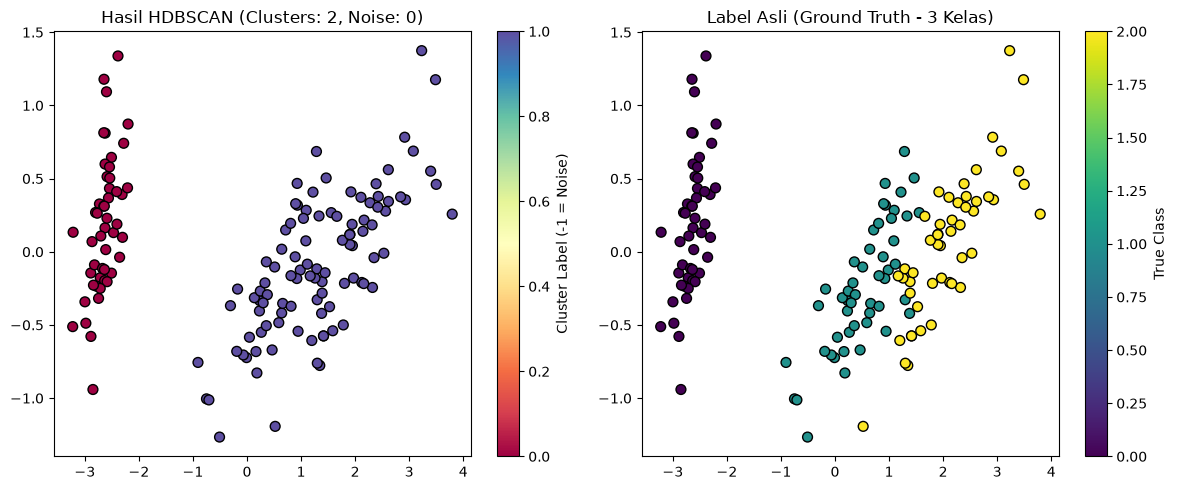

In [5]:
# Visualisasi: Reduksi dimensi menggunakan PCA menjadi 2 fitur agar bisa diplot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 5))

# Plot hasil HDBSCAN 
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Spectral', s=50, edgecolor='k')
plt.title(f'Hasil HDBSCAN (Clusters: {n_clusters}, Noise: {n_noise})')
plt.colorbar(scatter, label='Cluster Label (-1 = Noise)')

# Plot Label Asli
plt.subplot(1, 2, 2)
scatter_true = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=50, edgecolor='k')
plt.title('Label Asli (Ground Truth - 3 Kelas)')
plt.colorbar(scatter_true, label='True Class')

plt.tight_layout()
plt.show()


---

**No.4 - Analisis Singkat**

Berdasarkan hasil visualisasi, algoritma HDBSCAN hanya membagi data menjadi dua cluster tanpa mendeteksi noise, padahal label aslinya memiliki tiga kelas. Kelompok data di sisi kiri berhasil dipisahkan secara akurat menjadi satu cluster tersendiri karena batas spasialnya sangat jelas. 

Sebaliknya, dua kelas di sisi kanan terpaksa digabungkan menjadi satu cluster karena titik datanya saling tumpang tindih (overlap) tanpa adanya celah kepadatan yang tegas. 

Hal ini menunjukkan bahwa HDBSCAN sangat andal dalam memisahkan kelompok data yang terisolasi, namun akan otomatis menggabungkan kelas-kelas berbeda jika area kepadatannya saling berkesinambungan.